In [33]:
import os
import random
import tarfile
import urllib.request
from pathlib import Path
import math
from collections import defaultdict

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [35]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [36]:
data_dir = Path("./")
data_dir.mkdir(parents=True,exist_ok=True)

In [37]:
url = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"
tar_path = data_dir/ "imagenette2-160.tgz"
extract_path = data_dir/"imagenette2-160"

if not extract_path.exists():

  print("Downloading ImageNette")

  urllib.request.urlretrieve(url, tar_path)

  print("Extracting")

  with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(data_dir)



print(extract_path)
print(extract_path/"train")


imagenette2-160
imagenette2-160/train


In [38]:
image_size = 32

# Resizing images to 32X32 and normalizing it to [-1,1].
transform = transforms.Compose([
    transforms.Resize((image_size,image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [39]:
train_data = extract_path / "train"
full_dataset = datasets.ImageFolder(root=train_data, transform = transform)

print("Total Images:", len(full_dataset))
print("Classes:", full_dataset.classes)

Total Images: 9469
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


# Three Training Examples Overfit


In [40]:
# Selecting 3 Images

selected_images = []
selected_labels = []
seen_classes = set()

for img, label in full_dataset:

  if label not in seen_classes:
    selected_images.append(img)
    selected_labels.append(label)
    seen_classes.add(label)

  if len(selected_images) == 3:
    break


selected_images = torch.stack(selected_images, dim=0)
selected_labels = torch.tensor(selected_labels)

print("Selected Images Shapes: ", selected_images.shape)
print("Selected Labels: ", selected_labels.tolist())
print("Selected Class Names: ", [full_dataset.classes[i] for i in selected_labels.tolist()] )

Selected Images Shapes:  torch.Size([3, 3, 32, 32])
Selected Labels:  [0, 1, 2]
Selected Class Names:  ['n01440764', 'n02102040', 'n02979186']


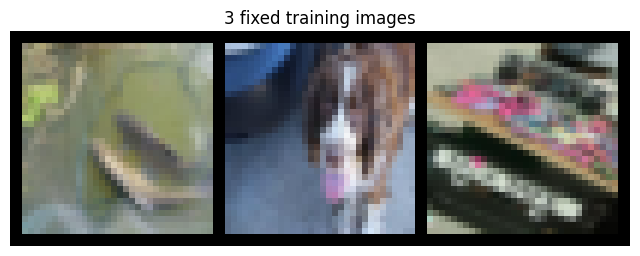

In [41]:
def denorm(x):
    return (x + 1) / 2

grid = make_grid(denorm(selected_images).clamp(0, 1), nrow=3)

plt.figure(figsize=(8, 3))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("3 fixed training images")
plt.show()

In [42]:
class ImageDataset(Dataset):
    def __init__(self, images, labels=None):
        self.images = images
        self.labels = labels

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        if self.labels is None:
            return self.images[idx]
        return self.images[idx], self.labels[idx]


In [43]:
three_image_dataset = ImageDataset(selected_images, selected_labels)
three_image_dataloader = DataLoader(three_image_dataset, batch_size=3, shuffle=True, drop_last=True)

In [44]:
batch = next(iter(three_image_dataloader))
X,y = batch

print("X: ", X.shape)
print("y: ", y)

X:  torch.Size([3, 3, 32, 32])
y:  tensor([1, 2, 0])


In [45]:
# MeanFlow Data Construction

x = selected_images.to(device) # Real Images
B = x.shape[0]
eps = torch.randn_like(x) # Gaussian Noise

t = torch.rand(B, device=device)
r = torch.rand(B, device=device)

# Making sure r<=t
t_final = torch.maximum(t,r)
r_final = torch.minimum(t,r)

t_img = t_final[:, None, None, None] # Because our x shape would be [Batch_size, Channels,Height,Width]

z_t = (1-t_img) * x + t_img * eps # Interpolated Sample

v = eps - x # Conditional Velocity

print("x:", x.shape)
print("eps:", eps.shape)
print("z_t:", z_t.shape)
print("v:", v.shape)
print("r:", r_final)
print("t:", t_final)

x: torch.Size([3, 3, 32, 32])
eps: torch.Size([3, 3, 32, 32])
z_t: torch.Size([3, 3, 32, 32])
v: torch.Size([3, 3, 32, 32])
r: tensor([0.8259, 0.1289, 0.5621], device='cuda:0')
t: tensor([0.9877, 0.2128, 0.7292], device='cuda:0')


In [46]:
print(x.min(), x.max())
print(eps.mean(), eps.std())
print(z_t.min(), z_t.max())

tensor(-0.9686, device='cuda:0') tensor(0.9373, device='cuda:0')
tensor(0.0033, device='cuda:0') tensor(0.9906, device='cuda:0')
tensor(-3.3838, device='cuda:0') tensor(3.0003, device='cuda:0')


In [47]:
# Make a Sinusoidal Embedding because a neural network doesn't learn very rich patterns from a single scalar t.

class SinusoidalEmbedding(nn.Module):

  def __init__(self, dim: int):
    super().__init__()
    self.dim = dim

  def forward(self, x):

    half_dim = self.dim // 2 # Half sin wave and half cos wave
    device = x.device

    freqs = torch.exp(
        -math.log(1000) * torch.arange(half_dim, device=device) / (half_dim - 1)
    ) # Forms frequency something like positional encoding

    args = x[:, None] * freqs[None, :] # Multiply each time value with each frequency to create sinusoidal inputs

    emb = torch.cat([torch.sin(args), torch.cos(args)], dim = -1)

    if self.dim % 2 == 1:
      emb = F.pad(emb, (0,1)) # In case embedding dim is not divisible by 2, we will add an extra pad

    return emb



In [48]:
emb_layer = SinusoidalEmbedding(dim=8)
times = torch.tensor([0.0,0.5,1.0])
emb = emb_layer(times)

print("Times Shape: ", times.shape)
print("Embedding Shape: ", emb.shape)
print(emb)

Times Shape:  torch.Size([3])
Embedding Shape:  torch.Size([3, 8])
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
         1.0000e+00, 1.0000e+00],
        [4.7943e-01, 4.9979e-02, 5.0000e-03, 5.0000e-04, 8.7758e-01, 9.9875e-01,
         9.9999e-01, 1.0000e+00],
        [8.4147e-01, 9.9833e-02, 9.9998e-03, 1.0000e-03, 5.4030e-01, 9.9500e-01,
         9.9995e-01, 1.0000e+00]])


In [49]:
class ResBlock(nn.Module):

    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()

        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        if in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, temb):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)


        time_bias = self.time_proj(temb)[:, :, None, None]
        h = h + time_bias

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + self.skip(x)

In [50]:
class MeanFlowUNet(nn.Module):

    def __init__(
        self,
        img_channels=3,
        base_channels=64,
        time_emb_dim=64,
        num_classes=3,
    ):
        super().__init__()

        self.time_embed = SinusoidalEmbedding(time_emb_dim)

        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim*2, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim),
        )

        self.label_embed = nn.Embedding(num_classes, time_emb_dim)

        self.in_conv = nn.Conv2d(img_channels, base_channels, kernel_size=3, padding=1)

        self.res1 = ResBlock(base_channels, base_channels, time_emb_dim)
        self.down1 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1)

        self.res2 = ResBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=4, stride=2, padding=1)

        self.mid = ResBlock(base_channels * 4, base_channels * 4, time_emb_dim)

        self.up1 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1)
        self.res_up1 = ResBlock(base_channels * 2, base_channels * 2, time_emb_dim)

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1)
        self.res_up2 = ResBlock(base_channels, base_channels, time_emb_dim)

        self.out_norm = nn.GroupNorm(8, base_channels)
        self.out_conv = nn.Conv2d(base_channels, img_channels, kernel_size=3, padding=1)

    def forward(self, z, r, t, y=None):

        dt = t - r

        #t_emb = t
        #dt_emb = dt

        t_emb = self.time_embed(t)
        dt_emb = self.time_embed(dt)


        #temb = torch.stack([t, dt], dim=1)  # [B, 2]
        temb = torch.cat([t_emb, dt_emb], dim=-1)
        temb = self.time_mlp(temb)

        if y is not None:
            temb = temb + self.label_embed(y)

        h1 = self.in_conv(z)
        h1 = self.res1(h1, temb)

        h2 = self.down1(h1)
        h2 = self.res2(h2, temb)

        h3 = self.down2(h2)
        h3 = self.mid(h3, temb)

        h = self.up1(h3)
        h = h + h2
        h = self.res_up1(h, temb)

        h = self.up2(h)
        h = h + h1
        h = self.res_up2(h, temb)

        h = self.out_norm(h)
        h = F.silu(h)
        out = self.out_conv(h)

        return out

In [51]:
model = MeanFlowUNet(
    img_channels=3,
    base_channels=64,
    time_emb_dim=64,
    num_classes=3,
).to(device)

# Single example
B = 1
z = torch.randn(B, 3, 32, 32).to(device)

r = torch.tensor([0.2], device=device)
t = torch.tensor([0.7], device=device)

y = torch.tensor([0], dtype=torch.long, device=device)

out = model(z, r, t, y)

print("z shape:", z.shape)
print("r shape:", r.shape)
print("t shape:", t.shape)
print("output shape:", out.shape)

z shape: torch.Size([1, 3, 32, 32])
r shape: torch.Size([1])
t shape: torch.Size([1])
output shape: torch.Size([1, 3, 32, 32])


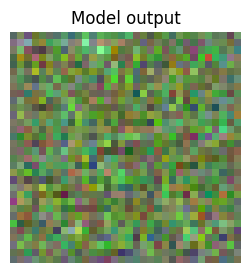

In [52]:
out_img = out[0].detach().cpu()
out_img = out_img.permute(1, 2, 0)

# Normalize for visualization only
out_img = (out_img - out_img.min()) / (out_img.max() - out_img.min())

plt.figure(figsize=(3, 3))
plt.imshow(out_img)
plt.axis("off")
plt.title("Model output")
plt.show()

In [53]:
def sample_r_t(batch_size, device, same_time_prob=0.4, endpoint_prob=0.25):
    a = torch.rand(batch_size, device=device)
    b = torch.rand(batch_size, device=device)

    t = torch.maximum(a, b)
    r = torch.minimum(a, b)

    # Some samples use r = t
    same_mask = torch.rand(batch_size, device=device) < same_time_prob
    r = torch.where(same_mask, t, r)

    # Some samples use the exact one-step generation interval r=0, t=1
    endpoint_mask = torch.rand(batch_size, device=device) < endpoint_prob
    r = torch.where(endpoint_mask, torch.zeros_like(r), r)
    t = torch.where(endpoint_mask, torch.ones_like(t), t)

    return r, t

In [54]:
def meanflow_loss(model, x, y=None, same_time_prob=0.75, endpoint_prob=0.25):

    B = x.shape[0]
    device = x.device

    eps = torch.randn_like(x)

    r, t = sample_r_t(
        B,
        device=device,
        same_time_prob=same_time_prob,
        endpoint_prob=endpoint_prob,
    )

    t_img = t[:, None, None, None]
    z_t = (1.0 - t_img) * x + t_img * eps
    v = eps - x

    def fn(z_in, r_in, t_in):
        return model(z_in, r_in, t_in, y)

    u, dudt = torch.func.jvp(
        fn,
        (z_t, r, t),
        (v, torch.zeros_like(r), torch.ones_like(t)),
    )

    dt = (t - r)[:, None, None, None]
    u_tgt = v - dt * dudt

    loss = ((u - u_tgt.detach()) ** 2).mean()

    return loss

In [55]:
x_batch = selected_images.to(device)
y_batch = torch.arange(x_batch.shape[0], device=device)

loss = meanflow_loss(model, x_batch, y_batch)

print("loss:", loss.item())

loss.backward()

total_grad_norm = 0.0
for p in model.parameters():
    if p.grad is not None:
        total_grad_norm += p.grad.norm().item()

print("grad norm:", total_grad_norm)

loss: 1.210878849029541
grad norm: 12.010767200554255


In [56]:
from tqdm.auto import tqdm
import torch

model = MeanFlowUNet(
    img_channels=3,
    base_channels=64,
    time_emb_dim=64,
    num_classes=3,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=0.0,
)

num_epochs = 5000

step_loss_history = []
epoch_loss_history = []
grad_norm_history = []

model.train()

pbar = tqdm(range(num_epochs))

for epoch in pbar:
    epoch_losses = []

    for x, y in three_image_dataloader:
        x = x.to(device)
        y = y.to(device)

        loss = meanflow_loss(model, x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        step_loss_history.append(loss.item())
        epoch_losses.append(loss.item())
        grad_norm_history.append(float(grad_norm))

    avg_epoch_loss = sum(epoch_losses) / len(epoch_losses)
    epoch_loss_history.append(avg_epoch_loss)

    if epoch % 50 == 0:
        pbar.set_description(
            f"epoch={epoch} loss={avg_epoch_loss:.6f} grad={float(grad_norm):.4f}"
        )

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:04d} | "
            f"Avg Loss: {avg_epoch_loss:.6f} | "
            f"Grad Norm: {float(grad_norm):.4f}"
        )

  0%|          | 0/5000 [00:00<?, ?it/s]

Epoch 0000 | Avg Loss: 1.264581 | Grad Norm: 3.0705
Epoch 0500 | Avg Loss: 0.020127 | Grad Norm: 0.3621
Epoch 1000 | Avg Loss: 0.016054 | Grad Norm: 0.5605
Epoch 1500 | Avg Loss: 0.007729 | Grad Norm: 0.1507
Epoch 2000 | Avg Loss: 0.005338 | Grad Norm: 0.0855
Epoch 2500 | Avg Loss: 0.004990 | Grad Norm: 0.3758
Epoch 3000 | Avg Loss: 0.005629 | Grad Norm: 0.3293
Epoch 3500 | Avg Loss: 0.054775 | Grad Norm: 0.6374
Epoch 4000 | Avg Loss: 0.004021 | Grad Norm: 0.2462
Epoch 4500 | Avg Loss: 0.014433 | Grad Norm: 0.2340


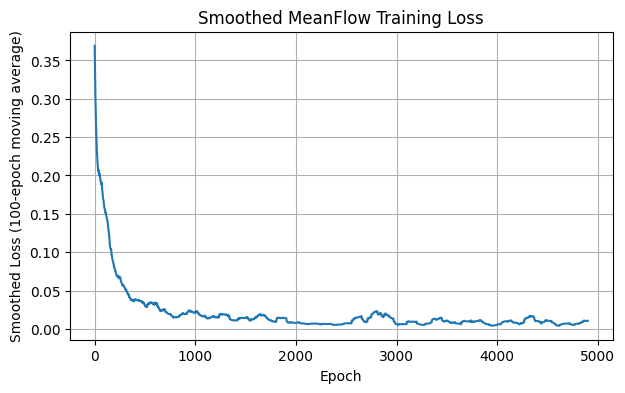

In [57]:
import numpy as np
import matplotlib.pyplot as plt

window = 100

loss_arr = np.array(epoch_loss_history)

if len(loss_arr) >= window:
    smooth_loss = np.convolve(loss_arr, np.ones(window) / window, mode="valid")

    plt.figure(figsize=(7, 4))
    plt.plot(smooth_loss)
    plt.xlabel("Epoch")
    plt.ylabel(f"Smoothed Loss ({window}-epoch moving average)")
    plt.title("Smoothed MeanFlow Training Loss")
    plt.grid(True)
    plt.show()

In [58]:
def denormalize_img(x):

    x = (x + 1) / 2
    return x.clamp(0, 1)

In [59]:
@torch.no_grad()
def generate_meanflow_samples(model, num_samples, device, y=None):
    model.eval()

    z = torch.randn(num_samples, 3, 32, 32, device=device)

    t = torch.ones(num_samples, device=device)
    r = torch.zeros(num_samples, device=device)
    u = model(z, r, t, y)
    x_gen = z - u

    return x_gen

In [60]:
x_orig, y_orig = next(iter(three_image_dataloader))
x_orig = x_orig.to(device)
y_orig = y_orig.to(device)


num_samples = x_orig.shape[0]

x_gen = generate_meanflow_samples(
    model=model,
    num_samples=num_samples,
    device=device,
    y=y_orig
)

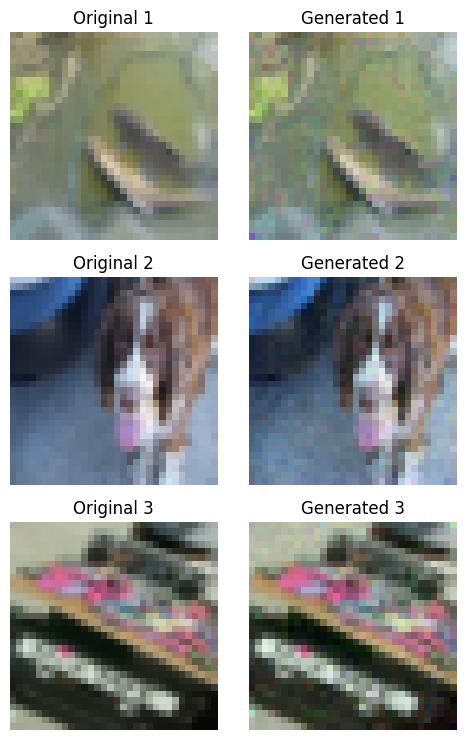

In [61]:
fig, axes = plt.subplots(num_samples, 2, figsize=(5, 2.5 * num_samples))

for i in range(num_samples):
    orig_img = denormalize_img(x_orig[i].detach().cpu()).permute(1, 2, 0)
    gen_img = denormalize_img(x_gen[i].detach().cpu()).permute(1, 2, 0)

    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gen_img)
    axes[i, 1].set_title(f"Generated {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()